In [ ]:
# ─────────────────────────────────────────────────────────────
# Colab install: pak + essential spatial/data packages
# ─────────────────────────────────────────────────────────────

if (!requireNamespace("pak", quietly = TRUE)) {
  install.packages("pak", repos = "https://cran.rstudio.com")
}

# Parallel, binary install of just what we need:
pak::pkg_install(c(
  "tidyverse",       # data wrangling & ggplot2
  "readxl",          # Excel import
  "sf",              # simple-features spatial
  "sp",              # legacy spatial (for gstat)
  "gstat",           # variogram & kriging
  "rnaturalearth",   # country boundaries
  "rnaturalearthdata",
  "ggspatial",       # scale bars / north arrows
  "viridis",         # color scales
  "patchwork",       # combine ggplots
  "fields"           # thin-plate splines (if you need TPS)
))


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



✔ Updated metadata database: 3.16 MB in 8 files.



ℹ Updating metadata database

✔ Updating metadata database ... done



 

→ Will install 138 packages.

→ Will download 138 CRAN packages (123.96 MB).

+ abind               1.4-8   [bld][dl] (21.97 kB)
+ askpass             1.2.1   [bld][cmp][dl] (6.06 kB)
+ backports           1.5.0   [bld][cmp][dl] (30.69 kB)
+ base64enc           0.1-3   [bld][cmp][dl] (7.83 kB)
+ bit                 4.6.0   [bld][cmp][dl] (304.58 kB)
+ bit64               4.6.0-1 [bld][cmp][dl] (142.04 kB)
+ blob                1.2.4   [bld][dl] (10.62 kB)
+ broom               1.0.8   [bld][dl] (651.24 kB)
+ bslib               0.9.0   [bld][dl] (5.43 MB)
+ cachem              1.1.0   [bld][cmp][dl] (27.19 kB)
+ callr               3.7.6   [bld][dl] (104.36 kB)
+ cellranger          1.1.0   [bld][dl] (63.86 kB)
+ class               7.3-23  [bld][cmp][dl] (22.06 kB)
+ classInt  

In [ ]:
# ---------------------------------------------
# USCRN Temperature Geospatial Analysis in R
# Google Colab–friendly
# ---------------------------------------------

# 2. Load libraries
library(tidyverse)
library(readxl)
library(sf)
library(sp)            # required by gstat
library(gstat)
library(rnaturalearth)
library(rnaturalearthdata)
library(ggspatial)
library(viridis)
library(patchwork)
library(fields)        # for Tps()

# 3. Set a consistent theme
theme_set(
  theme_minimal(base_size = 14, base_family = "serif") +
    theme(
      plot.title.position = "plot",
      plot.title = element_text(face = "bold"),
      panel.grid.major = element_line(colour = "grey85"),
      panel.grid.minor = element_blank()
    )
)

# 4. Read & prepare data
# (Adjust path if you save your CSV in Google Drive)
temp_df <- read_csv("/content/USCRN_2015_airtemp.csv", show_col_types = FALSE) %>%
  mutate(
    DATE = as.Date(DATE),
    T_DAILY_MEAN = as.numeric(T_DAILY_MEAN)
  )

# 5. Quick EDA: histogram & violin+boxplot
g_hist <- ggplot(temp_df, aes(T_DAILY_MEAN)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white") +
  geom_vline(aes(xintercept = mean(T_DAILY_MEAN, na.rm = TRUE)),
             linetype = "dashed", size = 0.6) +
  labs(title = "Histogram of Daily Mean Temperature (2015)",
       x = "Temperature (°C)", y = "Count")

g_violin <- ggplot(temp_df, aes(x = factor(1), y = T_DAILY_MEAN)) +
  geom_violin(fill = "lightblue", width = 0.8, alpha = 0.6) +
  geom_boxplot(width = 0.15, outlier.shape = 21,
               outlier.fill = "white", size = 0.4) +
  labs(x = NULL, y = "Temperature (°C)")

(g_hist | g_violin) + plot_annotation(tag_levels = "A")

# 6. Subset to 1 Jan 2015 and convert to sf
df1 <- temp_df %>%
  filter(DATE == as.Date("2015-01-01")) %>%
  drop_na(LONGITUDE, LATITUDE, T_DAILY_MEAN)

stations_sf <- st_as_sf(df1, coords = c("LONGITUDE","LATITUDE"), crs = 4326)

# 7. Linear trend surface
mod_lin <- lm(T_DAILY_MEAN ~ LONGITUDE + LATITUDE, data = df1)

grid_sf <- st_make_grid(stations_sf, n = c(100,100), what = "centers") %>%
  st_as_sf() %>%
  rename(geometry = x) %>%
  mutate(
    LONGITUDE = st_coordinates(geometry)[,1],
    LATITUDE  = st_coordinates(geometry)[,2],
    pred_lin  = predict(mod_lin, newdata = cur_data())
  )

usa_sf <- ne_countries(country = "United States of America", scale = "medium",
                       returnclass = "sf")

g_lin <- ggplot() +
  geom_sf(data = usa_sf, fill = "grey97", color = "grey60") +
  geom_tile(data = grid_sf, aes(LONGITUDE, LATITUDE, fill = pred_lin), alpha = 0.9) +
  scale_fill_viridis_c(option = "plasma", name = "°C") +
  geom_sf(data = stations_sf, shape = 21, fill = "white", size = 2, stroke = 0.3) +
  annotation_scale(location = "bl") +
  annotation_north_arrow(location = "tl") +
  labs(title = "Linear Trend Surface: 1 Jan 2015")
print(g_lin)

# 8. Thin-Plate Spline interpolation (optional)
tps_mod <- Tps(coordinates(as(stations_sf, "Spatial")), stations_sf$T_DAILY_MEAN)
coords <- st_coordinates(grid_sf)
grid_sf$pred_tps <- predict(tps_mod, coords)

g_tps <- ggplot() +
  geom_sf(data = usa_sf, fill = "grey97", color = "grey60") +
  geom_tile(data = grid_sf, aes(LONGITUDE, LATITUDE, fill = pred_tps), alpha = 0.9) +
  scale_fill_viridis_c(option = "viridis", name = "°C") +
  geom_sf(data = stations_sf, shape = 21, fill = "white", size = 2, stroke = 0.3) +
  annotation_scale(location = "bl") +
  annotation_north_arrow(location = "tl") +
  labs(title = "Thin-Plate Spline: 1 Jan 2015")
print(g_tps)

# 9. Variogram & spherical fit
stations_sp <- as(stations_sf, "Spatial")
vg_emp <- variogram(T_DAILY_MEAN ~ 1, stations_sp, cutoff = 2e6)
vg_mod <- fit.variogram(vg_emp, vgm(psill = 20, model = "Sph", range = 500e3, nugget = 5))
plot(vg_emp, vg_mod, main = "Empirical Variogram & Spherical Fit")

# 10. Ordinary Kriging
kriged <- krige(T_DAILY_MEAN ~ 1, stations_sp, as(grid_sf, "Spatial"), model = vg_mod)
kriged_sf <- st_as_sf(kriged)

g_ok <- ggplot() +
  geom_sf(data = usa_sf, fill = "grey97", color = "grey60") +
  geom_tile(data = mutate(kriged_sf, pred = var1.pred),
            aes(X1, X2, fill = pred), alpha = 0.9) +
  scale_fill_viridis_c(option = "magma", name = "°C") +
  geom_sf(data = stations_sf, shape = 21, fill = "white", size = 2, stroke = 0.3) +
  annotation_scale(location = "bl") +
  annotation_north_arrow(location = "tl") +
  labs(title = "Ordinary Kriging: 1 Jan 2015")
print(g_ok)

# End of notebook


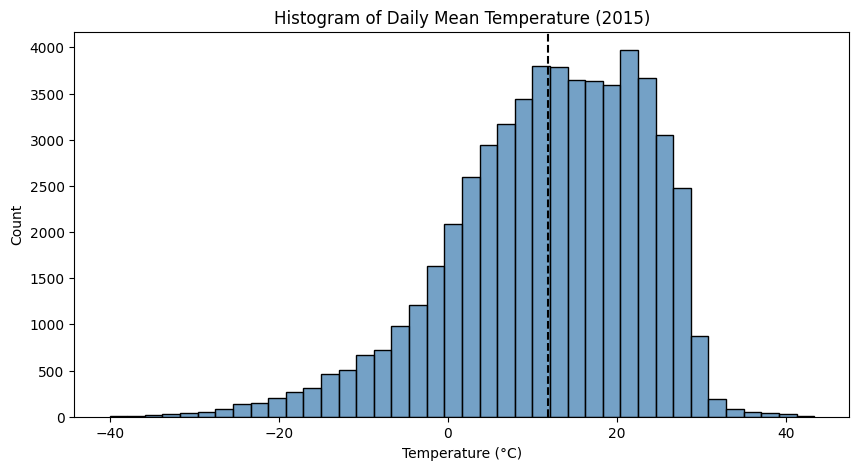

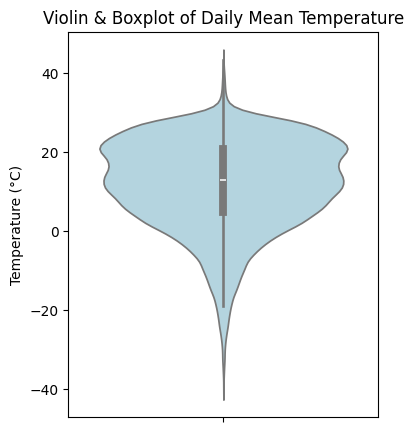

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


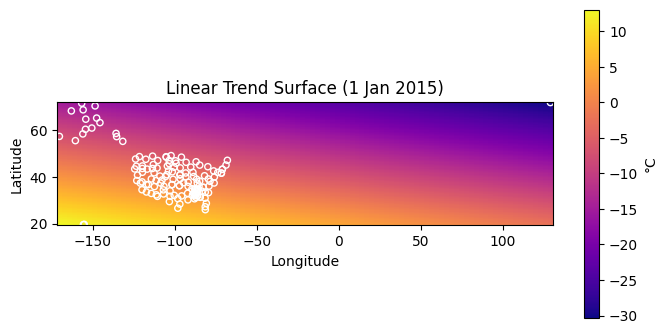

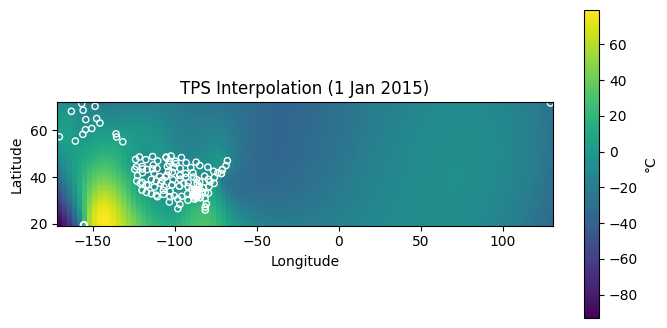

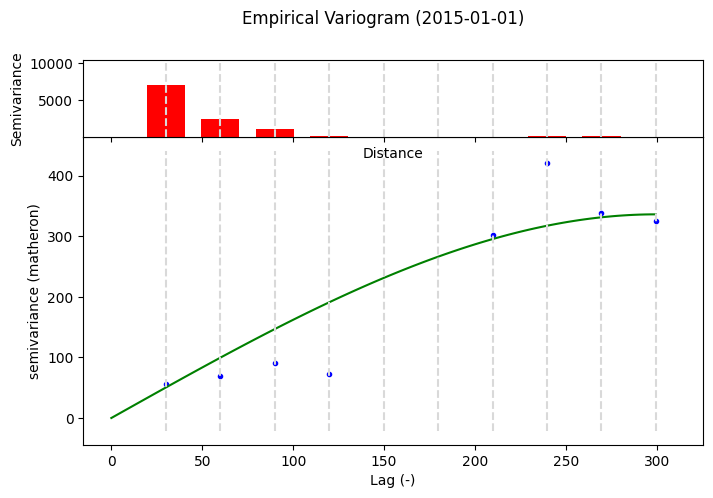

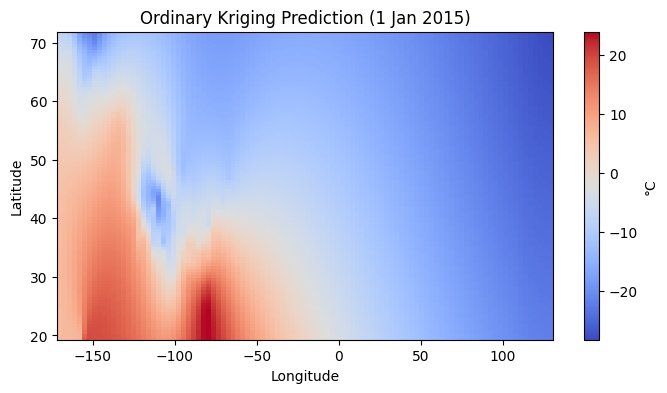

In [6]:
# 1. Install required libraries
!pip install pandas geopandas matplotlib seaborn scikit-learn scipy pykrige scikit-gstat

# 2. Imports
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import Rbf
from sklearn.linear_model import LinearRegression
from pykrige.ok import OrdinaryKriging
from skgstat import Variogram

# 3. Data Import
# Change this path if your file is elsewhere (e.g. '/content/drive/MyDrive/USCRN_2015_airtemp.csv')
temp_df = pd.read_csv('/content/USCRN_2015_airtemp.csv')
temp_df['DATE'] = pd.to_datetime(temp_df['DATE'], errors='coerce')

# 4. Quick EDA
plt.figure(figsize=(10,5))
sns.histplot(temp_df['T_DAILY_MEAN'], bins=40, color='steelblue')
plt.axvline(temp_df['T_DAILY_MEAN'].mean(), linestyle='--', color='black')
plt.title('Histogram of Daily Mean Temperature (2015)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(4,5))
sns.violinplot(y=temp_df['T_DAILY_MEAN'], inner='box', color='lightblue')
plt.title('Violin & Boxplot of Daily Mean Temperature')
plt.ylabel('Temperature (°C)')
plt.show()

# 5. Spatial Trend Surface (1 Jan 2015)
day1 = temp_df[temp_df['DATE'] == '2015-01-01'].dropna(subset=['LONGITUDE','LATITUDE','T_DAILY_MEAN'])
gdf  = gpd.GeoDataFrame(day1, geometry=gpd.points_from_xy(day1.LONGITUDE, day1.LATITUDE), crs="EPSG:4326")

# Fit linear model
X = day1[['LONGITUDE','LATITUDE']]
y = day1['T_DAILY_MEAN']
linreg = LinearRegression().fit(X, y)

# Create prediction grid
minx, miny, maxx, maxy = gdf.total_bounds
xi = np.linspace(minx, maxx, 100)
yi = np.linspace(miny, maxy, 100)
xx, yy = np.meshgrid(xi, yi)
pred_lin = linreg.predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# Plot
plt.figure(figsize=(8,4))
plt.pcolormesh(xx, yy, pred_lin, cmap='plasma', shading='auto')
gdf.plot(ax=plt.gca(), facecolor='none', edgecolor='white', markersize=20)
plt.colorbar(label='°C')
plt.title('Linear Trend Surface (1 Jan 2015)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# 6. Thin‐Plate Spline (TPS) Interpolation
rbf = Rbf(day1.LONGITUDE, day1.LATITUDE, day1.T_DAILY_MEAN, function='thin_plate')
tps_pred = rbf(xx, yy)

plt.figure(figsize=(8,4))
plt.pcolormesh(xx, yy, tps_pred, cmap='viridis', shading='auto')
gdf.plot(ax=plt.gca(), facecolor='none', edgecolor='white', markersize=20)
plt.colorbar(label='°C')
plt.title('TPS Interpolation (1 Jan 2015)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# 7. Empirical Variogram
coords = day1[['LONGITUDE','LATITUDE']].values
vario = Variogram(coords, day1['T_DAILY_MEAN'], normalize=False, maxlag=3000000)
fig = vario.plot()
fig.suptitle('Empirical Variogram (2015-01-01)')
plt.xlabel('Distance')
plt.ylabel('Semivariance')
plt.show()

# 8. Ordinary Kriging
OK = OrdinaryKriging(
    day1.LONGITUDE, day1.LATITUDE, day1.T_DAILY_MEAN,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False
)
z, ss = OK.execute('grid', xi, yi)

plt.figure(figsize=(8,4))
plt.pcolormesh(xx, yy, z, cmap='coolwarm', shading='auto')
plt.colorbar(label='°C')
plt.title('Ordinary Kriging Prediction (1 Jan 2015)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
